In this notebook we estimate step-by-step a kernel $\epsilon$-machine on toy dataset. It was introduced by [Brodu and Crutchfield (2022)](https://doi.org/10.1063/5.0062829) as a continuous-time general-alphabet extension of earlier works on discrete $\epsilon$-machines by [Crutchfield and Young (1989)](https://doi.org/10.1103/PhysRevLett.63.105) and [Shalizi and Crutchfield (2001)](https://doi.org/10.1023/A:1010388907793).

Briefly speaking, an $\epsilon$-machine is a minimal maximally-predictive representation of a stationary stochastic process.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist, pdist
from scipy.linalg import eigh
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler

## 0. Generate toy dataset

Let's generate a univariate time series $(z_t)_{t=0}^{N-1}$ with two switching regimes:

- Regime A (calm): $z_t \mid s_t = A \sim \mathcal{N}(\mu_A, \sigma_A^2)$, where $\mu_A = 0.5$ and $\sigma_A = 0.3$.
- Regime B (turbulent): $z_t \mid s_t = B \sim \mathcal{N}(\mu_B, \sigma_B^2)$, where $\mu_B = -0.5$ and $\sigma_B = 1.0$.

The hidden regime sequence $(s_t)$ follows a two-state Markov chain with transition matrix
$$
T_{\mathrm{true}} =
\begin{bmatrix}
0.98 & 0.02 \\
0.05 & 0.95
\end{bmatrix}.
$$

The initial distribution is $\pi_0 = (1, 0)$, so the process starts in Regime A at $t = 0$.

In [2]:
np.random.seed(2137)

# Parameters
N = 2000  # length of the time-serie

mu_A, sigma_A = 0.5, 0.3
mu_B, sigma_B = -0.5, 1.0

p_stay_A = 0.98
p_stay_B = 0.95

# Generate
states_true = np.zeros(N, dtype=int)  # 0=A, 1=B
series = np.zeros(N)

state = 0
for t in range(N):
    states_true[t] = state
    if state == 0:
        series[t] = np.random.normal(mu_A, sigma_A)
        if np.random.rand() > p_stay_A:
            state = 1
    else:
        series[t] = np.random.normal(mu_B, sigma_B)
        if np.random.rand() > p_stay_B:
            state = 0

On the below chart, the top panel is the observed series $z_t$; the bottom panel shows the true hidden regime.

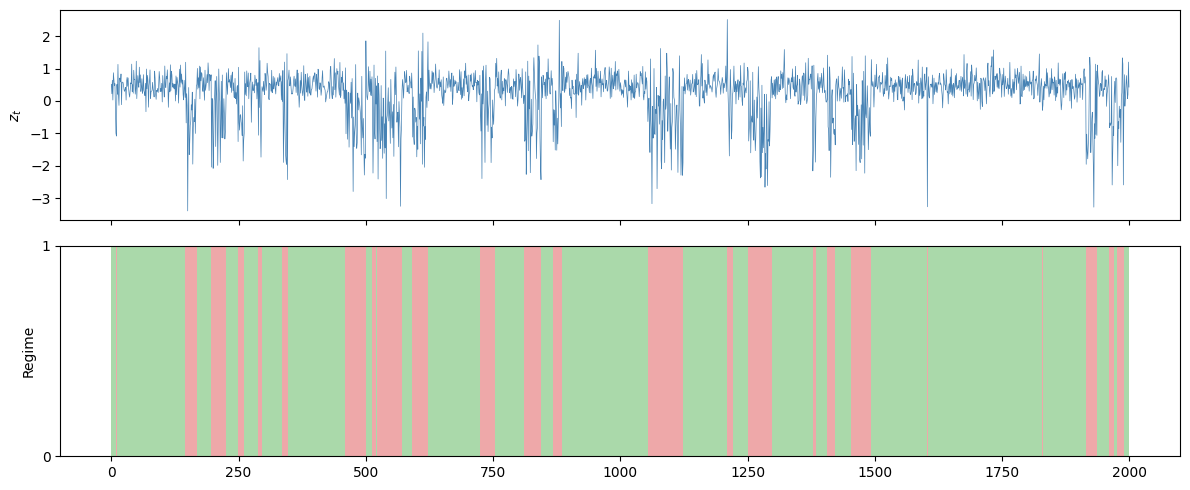

In [3]:
# Visualize
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 5), sharex=True)

ax1.plot(series, lw=0.5, color='steelblue')
ax1.set_ylabel('$z_t$')

colors = ['#2ca02c', '#d62728']
for t in range(N):
    ax2.axvspan(t - 0.5, t + 0.5, color=colors[states_true[t]], alpha=0.4, lw=0)
ax2.set_ylabel('Regime')
ax2.set_yticks([0, 1])
plt.tight_layout()
plt.show()

In [4]:
print(f"Regime proportions: A={np.mean(states_true==0):.1%}, B={np.mean(states_true==1):.1%}")

Regime proportions: A=73.5%, B=26.5%


## 1. Delay embeddings

For each valid time index $t$, define a past window and a future window:

$$
\mathbf{x}_t = (z_{t-L_{\mathrm{past}}+1}, \ldots, z_t) \in \mathbb{R}^{L_{\mathrm{past}}},
\qquad
\mathbf{y}_t = (z_{t+1}, \ldots, z_{t+L_{\mathrm{future}}}) \in \mathbb{R}^{L_{\mathrm{future}}}.
$$

This gives $n = N - L_{\mathrm{past}} - L_{\mathrm{future}} + 1 $ pairs $(\mathbf{x}_t, \mathbf{y}_t)$.

In [5]:
L_past = 5   # how far we look into the past
L_future = 5 # how far we look into the future

total_L = L_past + L_future
n = N - total_L + 1
print(f"L_past={L_past}, L_future={L_future}, n_points={n}")

# Past matrix
X_past = np.zeros((n, L_past))
for i in range(L_past):
    X_past[:, i] = series[i: i + n]

# Future matrix
X_future = np.zeros((n, L_future))
for i in range(L_future):
    offset = L_past + i
    X_future[:, i] = series[offset: offset + n]

# True regimes
states_embedded = states_true[L_past - 1: L_past - 1 + n]

print(f"X_past shape:   {X_past.shape}")
print(f"X_future shape: {X_future.shape}")

L_past=5, L_future=5, n_points=1991
X_past shape:   (1991, 5)
X_future shape: (1991, 5)


Standardize both past and future windows for numerical stability before computing kernels and diffusion distances.

In [6]:
scaler_past = StandardScaler()
scaler_future = StandardScaler()
X_past_s = scaler_past.fit_transform(X_past)
X_future_s = scaler_future.fit_transform(X_future)

Below scatter plots show only the first two coordinates of each embedding vector. Some overlap is expected; the main thing to look for is whether the geometry already hints at different predictive regimes before we apply kernels.

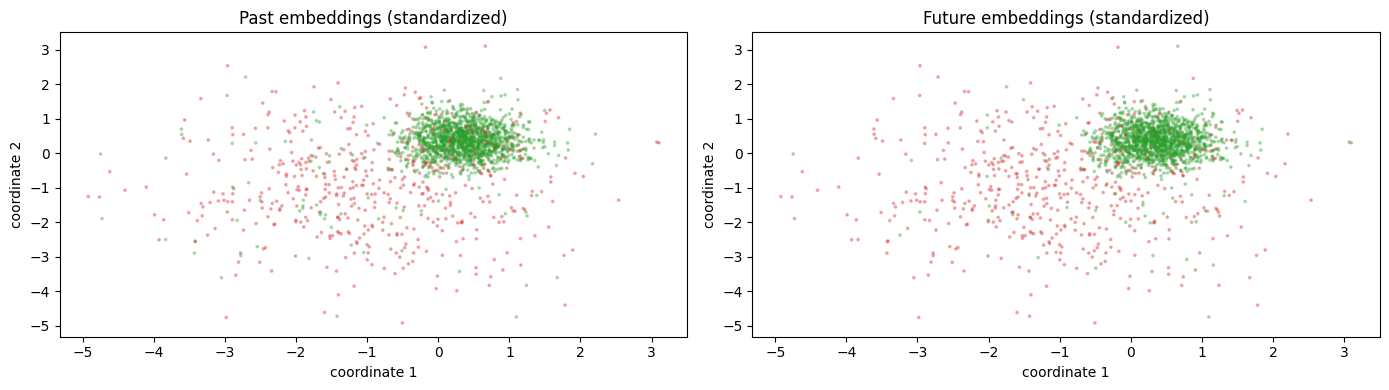

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, data, title in [(axes[0], X_past_s, 'Past embeddings (standardized)'),
                         (axes[1], X_future_s, 'Future embeddings (standardized)')]:
    colors_plot = ['#2ca02c' if s == 0 else '#d62728' for s in states_embedded]
    ax.scatter(data[:, 0], data[:, 1], c=colors_plot, s=3, alpha=0.3)
    ax.set_xlabel('coordinate 1')
    ax.set_ylabel('coordinate 2')
    ax.set_title(title)
plt.tight_layout()
plt.show()

## 2. RBF kernel

The Gaussian (RBF) kernels are defined by

$$
G^X_{ij} = \exp\!\left(-\frac{\|\mathbf{x}_i - \mathbf{x}_j\|^2}{2\,\xi_X^2}\right), \qquad
G^Y_{ij} = \exp\!\left(-\frac{\|\mathbf{y}_i - \mathbf{y}_j\|^2}{2\,\xi_Y^2}\right).
$$

As suggested by [Gretton et al., (2012)](https://jmlr.csail.mit.edu/papers/volume13/gretton12a/gretton12a.pdf), we estimate the bandwidths $\xi_X$ and $\xi_Y$ with the median heuristic, that is, the median pairwise Euclidean distance in the corresponding sample. This gives a simple data-adaptive notion of similarity.

In [8]:
def rbf_kernel(X, Y=None, bandwidth=1.0):
    if Y is None:
        Y = X
    dists_sq = cdist(X, Y, 'sqeuclidean')
    return np.exp(-dists_sq / (2.0 * bandwidth ** 2))

def median_heuristic(X):
    dists = pdist(X, 'euclidean')
    return np.median(dists)

# Bandwidth
bw_past = median_heuristic(X_past_s)
bw_future = median_heuristic(X_future_s)
print(f"Bandwidth past:   ξ_X = {bw_past:.4f}")
print(f"Bandwidth future: ξ_Y = {bw_future:.4f}")

# Kernel matrices
K_past = rbf_kernel(X_past_s, bandwidth=bw_past)
K_future = rbf_kernel(X_future_s, bandwidth=bw_future)

print(f"\nK_past shape:   {K_past.shape}  (value range: {K_past.min():.4f} – {K_past.max():.4f})")
print(f"K_future shape: {K_future.shape}  (value range: {K_future.min():.4f} – {K_future.max():.4f})")

Bandwidth past:   ξ_X = 2.1031
Bandwidth future: ξ_Y = 2.1036

K_past shape:   (1991, 1991)  (value range: 0.0000 – 1.0000)
K_future shape: (1991, 1991)  (value range: 0.0000 – 1.0000)


In below heatmaps, brighter values indicate pairs of windows that are more similar under the RBF kernel.

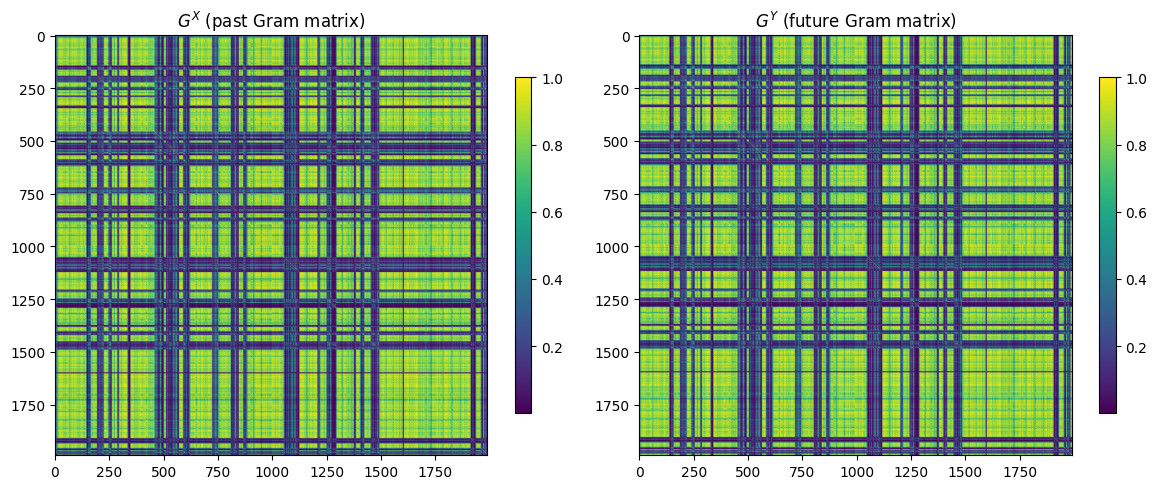

In [9]:
# Visualize kernel matrices
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
im1 = ax1.imshow(K_past, cmap='viridis', aspect='auto')
ax1.set_title('$G^X$ (past Gram matrix)')
plt.colorbar(im1, ax=ax1, shrink=0.8)

im2 = ax2.imshow(K_future, cmap='viridis', aspect='auto')
ax2.set_title('$G^Y$ (future Gram matrix)')
plt.colorbar(im2, ax=ax2, shrink=0.8)
plt.tight_layout()
plt.show()

## 3. Conditional weights matrix $\Omega$

Now we approximate the conditional mean embedding of $P(\mathbf{Y} \mid \mathbf{X} = \mathbf{x})$ in the RKHS associated with the future kernel:

$$
\widehat{\mu}_{Y\mid X=\mathbf{x}} = \sum_{i=1}^{n} \omega_i(\mathbf{x})\, k^Y(\mathbf{y}_i, \cdot).
$$

The weights are obtained from a regularized kernel regression step:

$$
\Omega = (G^X + n\varepsilon I)^{-1}\, G^X.
$$

Intuitively, column $j$ of $\Omega$ tells us how the training futures should be averaged to represent the future distribution associated with past window $\mathbf{x}_j$.

In [10]:
regularization = 1e-4
reg = regularization * n * np.eye(n)
Omega = np.linalg.solve(K_past + reg, K_past)

print(f"Omega shape: {Omega.shape}")
print(f"Omega values: min={Omega.min():.4f}, max={Omega.max():.4f}, mean={Omega.mean():.4f}")

Omega shape: (1991, 1991)
Omega values: min=-0.0411, max=0.7115, mean=0.0005


Below each panel shows one column of $\Omega$. Sharp peaks mean the conditional embedding relies on a small set of very similar past windows, while broader profiles indicate a more diffuse predictive neighborhood.

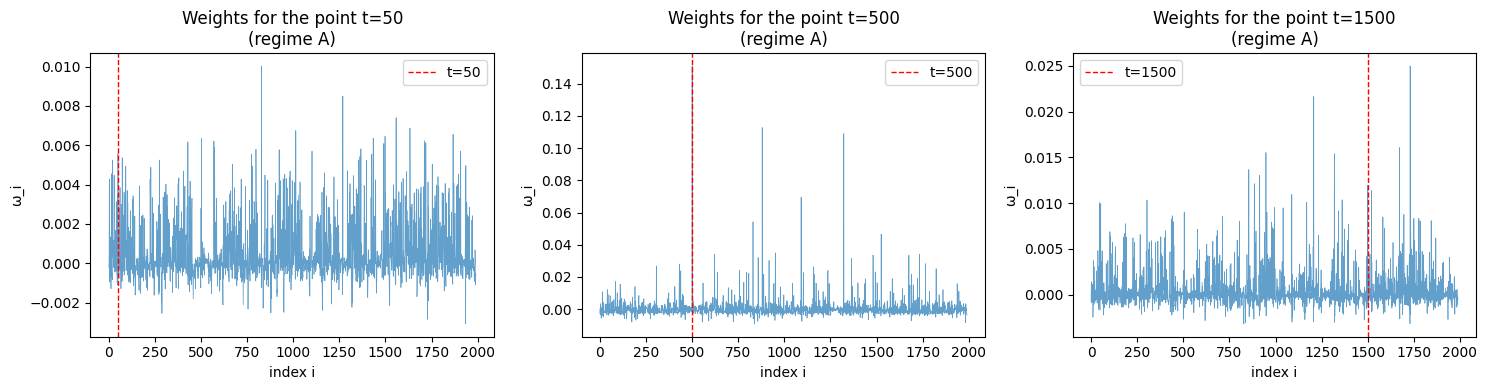

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, idx in zip(axes, [50, 500, 1500]):
    weights = Omega[:, idx]
    ax.plot(weights, lw=0.5, alpha=0.7)
    ax.axvline(idx, color='red', ls='--', lw=1, label=f't={idx}')
    ax.set_title(f'Weights for the point t={idx}\n(regime {"A" if states_embedded[idx]==0 else "B"})')
    ax.set_xlabel('index i')
    ax.set_ylabel('ω_i')
    ax.legend()
plt.tight_layout()
plt.show()

## 4. Gram matrix for the causal states $G^{\mathcal{S}}$

Now compute inner products between the conditional embeddings:

$$
G^{\mathcal{S}} = \Omega^\top\, G^Y\, \Omega.
$$

Entry $G^{\mathcal{S}}_{ij}$ is large when past windows $\mathbf{x}_i$ and $\mathbf{x}_j$ induce similar future distributions. In that sense, this Gram matrix measures similarity between inferred causal states.

In [12]:
G_S = Omega.T @ K_future @ Omega

print(f"G^S shape: {G_S.shape}")
print(f"G^S values: min={G_S.min():.4f}, max={G_S.max():.4f}")

G^S shape: (1991, 1991)
G^S values: min=0.0173, max=0.8410


On below cahrt, a clean block structure indicates that groups of past windows share similar predictive futures. Sorting by the true regime lets us check whether the kernel construction has recovered the latent two-state organization.

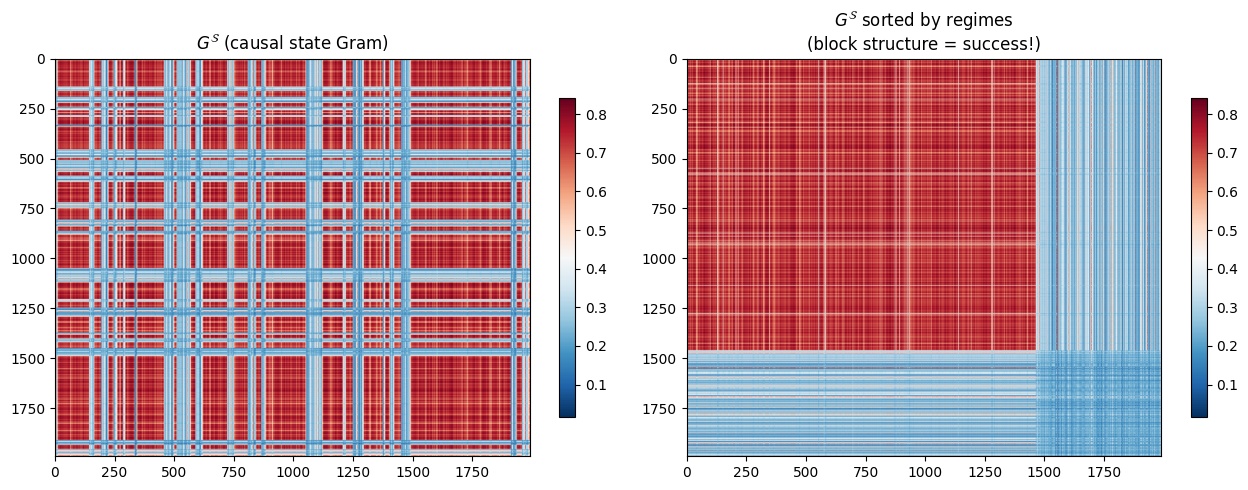

In [13]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

im1 = ax1.imshow(G_S, cmap='RdBu_r', aspect='auto')
ax1.set_title(f'$G^{{\\mathcal{{S}}}}$ (causal state Gram)')
plt.colorbar(im1, ax=ax1, shrink=0.8)

# Compare with ground truth, sorted by regimes
order = np.argsort(states_embedded)
G_S_sorted = G_S[np.ix_(order, order)]
im2 = ax2.imshow(G_S_sorted, cmap='RdBu_r', aspect='auto')
ax2.set_title(f'$G^{{\\mathcal{{S}}}}$ sorted by regimes\n(block structure = success!)')
plt.colorbar(im2, ax=ax2, shrink=0.8)

plt.tight_layout()
plt.show()

## 5. Diffusion maps to reduce dimensionality

$G^{\mathcal{S}}$ is a Gram matrix in an infinite-dimensional RKHS, so it implicitly defines squared distances between causal-state embeddings. Diffusion maps ([Coifman & Lafon, 2006](https://doi.org/10.1016/j.acha.2006.04.006)) use those distances to uncover a low-dimensional geometry of predictive states.

Steps:
1. Convert similarities to squared RKHS distances: $D^2_{ij} = G^{\mathcal{S}}_{ii} - 2G^{\mathcal{S}}_{ij} + G^{\mathcal{S}}_{jj}$. If two conditional embeddings are close in RKHS, then $D_{ij}$ is small.
2. Build a diffusion kernel: $W_{ij} = \exp\!\left(-D^2_{ij} / (2\epsilon^2)\right)$. Nearby predictive states therefore exchange more probability mass.
3. Apply Coifman-Lafon normalization with $\alpha = 1$:

$$
q_i = \sum_j W_{ij}, \qquad
K^{(\alpha)}_{ij} = \frac{W_{ij}}{q_i^\alpha q_j^\alpha}, \qquad
P_{ij} = \frac{K^{(\alpha)}_{ij}}{\sum_\ell K^{(\alpha)}_{i\ell}}.
$$

   In the code we diagonalize the symmetric matrix

$$
L = D_P^{-1/2} K^{(\alpha)} D_P^{-1/2}, \qquad (D_P)_{ii} = \sum_j K^{(\alpha)}_{ij},
$$

   which has the same nontrivial eigenvalues as the Markov operator $P$. Intuitively, this step discounts sampling-density effects, so dense regions do not dominate the geometry just because they contain more points.

4. The nontrivial eigenvectors give diffusion coordinates at diffusion time $t = 1$:

$$
\sigma(i) = (\lambda_1 \psi_1(i), \ldots, \lambda_m \psi_m(i)).
$$

If only a few coordinates carry most of the structure, then the causal-state manifold is effectively low-dimensional.

In [14]:
n_components = 5

# Step 1
diag_GS = np.diag(G_S).copy()
D2 = diag_GS[:, None] - 2 * G_S + diag_GS[None, :]
D2 = np.maximum(D2, 0)  # numerical correction

# Step 2
dists_upper = D2[np.triu_indices(n, k=1)]
epsilon_diff = np.median(np.sqrt(dists_upper + 1e-12))
print(f"Diffusion bandwidth ε = {epsilon_diff:.4f}")

W = np.exp(-D2 / (2.0 * epsilon_diff ** 2))

# Step 3 (alpha=1)
D1 = W.sum(axis=1)
W_norm = W * (1.0 / D1)[:, None] * (1.0 / D1)[None, :]
D2_diag = W_norm.sum(axis=1)
D2_inv_sqrt = 1.0 / np.sqrt(D2_diag + 1e-12)
L = W_norm * D2_inv_sqrt[:, None] * D2_inv_sqrt[None, :]

# Step 4
n_comp = min(n_components + 1, n - 1)
eigenvalues, eigenvectors = eigh(L, subset_by_index=[n - n_comp, n - 1])

# Sort descending
idx_sort = np.argsort(-eigenvalues)
eigenvalues = eigenvalues[idx_sort]
eigenvectors = eigenvectors[:, idx_sort]

print(f"\nEigenvalues (top {n_comp}):")
for k, ev in enumerate(eigenvalues):
    marker = " ← trivial (λ₀≈1)" if k == 0 else ""
    print(f"  λ_{k} = {ev:.6f}{marker}")

# Diffusion coordinates (skip lambda_0)
diff_eigenvalues = eigenvalues[1:n_components + 1]
diff_coords = eigenvectors[:, 1:n_components + 1] * diff_eigenvalues[None, :]

print(f"\nDiffusion coords shape: {diff_coords.shape}")

Diffusion bandwidth ε = 0.2505

Eigenvalues (top 6):
  λ_0 = 1.000000 ← trivial (λ₀≈1)
  λ_1 = 0.870684
  λ_2 = 0.755975
  λ_3 = 0.713597
  λ_4 = 0.553602
  λ_5 = 0.510339

Diffusion coords shape: (1991, 5)


Read the three panels together: a spectral gap suggests the intrinsic dimension, separation in the first two diffusion coordinates indicates distinct predictive states, and the histogram of $\sigma_1$ shows how well one coordinate alone separates the regimes.

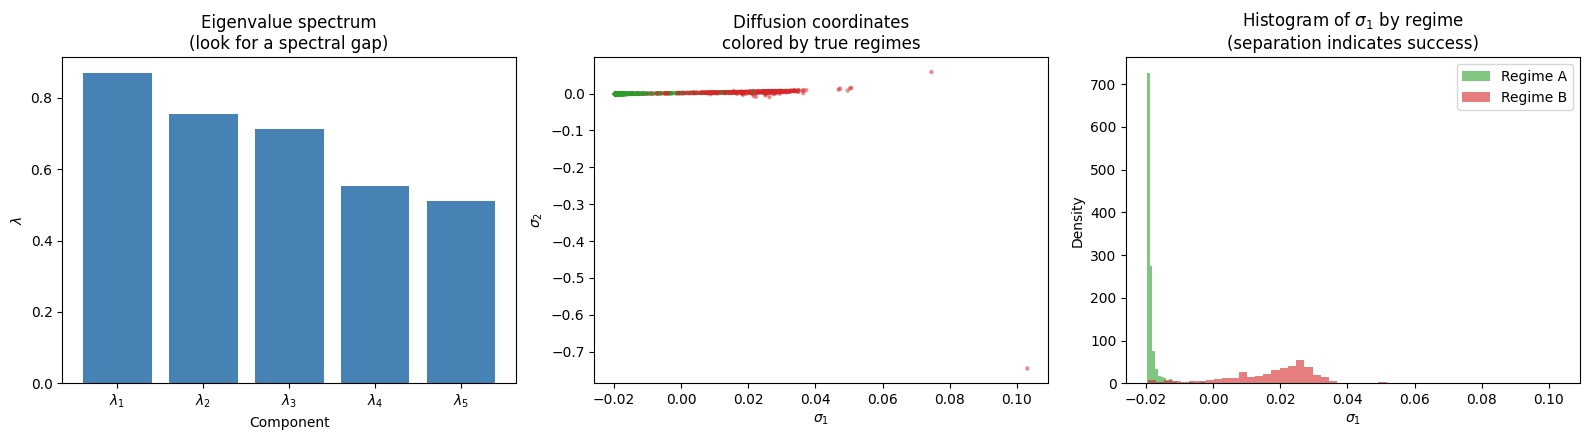

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# Eigenvalue spectrum
ax = axes[0]
ax.bar(range(len(diff_eigenvalues)), diff_eigenvalues, color='steelblue')
ax.set_xlabel('Component')
ax.set_ylabel(r'$\lambda$')
ax.set_title('Eigenvalue spectrum\n(look for a spectral gap)')
ax.set_xticks(range(len(diff_eigenvalues)))
ax.set_xticklabels([f'$\\lambda_{k+1}$' for k in range(len(diff_eigenvalues))])

# Diffusion coordinates: dim 1 vs dim 2, colored by true regimes
ax = axes[1]
colors_gt = ['#2ca02c' if s == 0 else '#d62728' for s in states_embedded]
ax.scatter(diff_coords[:, 0], diff_coords[:, 1], c=colors_gt, s=5, alpha=0.4)
ax.set_xlabel('$\\sigma_1$')
ax.set_ylabel('$\\sigma_2$')
ax.set_title('Diffusion coordinates\ncolored by true regimes')

# Histogram of the first diffusion coordinate
ax = axes[2]
mask_A = states_embedded == 0
mask_B = states_embedded == 1
ax.hist(diff_coords[mask_A, 0], bins=50, alpha=0.6, color='#2ca02c', label='Regime A', density=True)
ax.hist(diff_coords[mask_B, 0], bins=50, alpha=0.6, color='#d62728', label='Regime B', density=True)
ax.set_xlabel('$\\sigma_1$')
ax.set_ylabel('Density')
ax.set_title('Histogram of $\\sigma_1$ by regime\n(separation indicates success)')
ax.legend()

plt.tight_layout()
plt.show()

## 6. Clustering to discretize causal states

We now cluster the diffusion coordinates with DBSCAN using a fixed parameter choice.

In [16]:
cluster_dims = min(2, diff_coords.shape[1])
cluster_data = diff_coords[:, :cluster_dims]
cluster_data_s = StandardScaler().fit_transform(cluster_data)

eps_dbscan = 0.0702
min_samples = 22
labels = DBSCAN(eps=eps_dbscan, min_samples=min_samples).fit_predict(cluster_data_s)

n_noise = int(np.sum(labels == -1))
if n_noise:
    cluster_ids = np.array([label for label in np.unique(labels) if label != -1])
    centroids = np.vstack([cluster_data_s[labels == label].mean(axis=0) for label in cluster_ids])
    labels = labels.copy()
    labels[labels == -1] = cluster_ids[cdist(cluster_data_s[labels == -1], centroids).argmin(axis=1)]

_, labels = np.unique(labels, return_inverse=True)
n_states = len(np.unique(labels))

cluster_sizes = np.bincount(labels, minlength=n_states)
contingency = np.zeros((n_states, 2), dtype=int)
for state_id in range(n_states):
    for regime_id in range(2):
        contingency[state_id, regime_id] = np.sum((labels == state_id) & (states_embedded == regime_id))

accuracy = contingency.max(axis=1).sum() / len(labels)

print(f"\nDiscrete causal states found: {n_states}")
for state_id, size in enumerate(cluster_sizes):
    print(f"  State {state_id}: n={size}")
print("\nCluster vs. true regime counts [A, B]:")
print(contingency)
print(f"Accuracy relative to the true regimes: {accuracy:.1%}")


Discrete causal states found: 2
  State 0: n=1515
  State 1: n=476

Cluster vs. true regime counts [A, B]:
[[1451   64]
 [  10  466]]
Accuracy relative to the true regimes: 96.3%


The left panel shows the unsupervised DBSCAN partition in diffusion space, while the right panel shows the true regimes. Close visual agreement means the diffusion geometry is already separating predictive states before any supervised comparison.

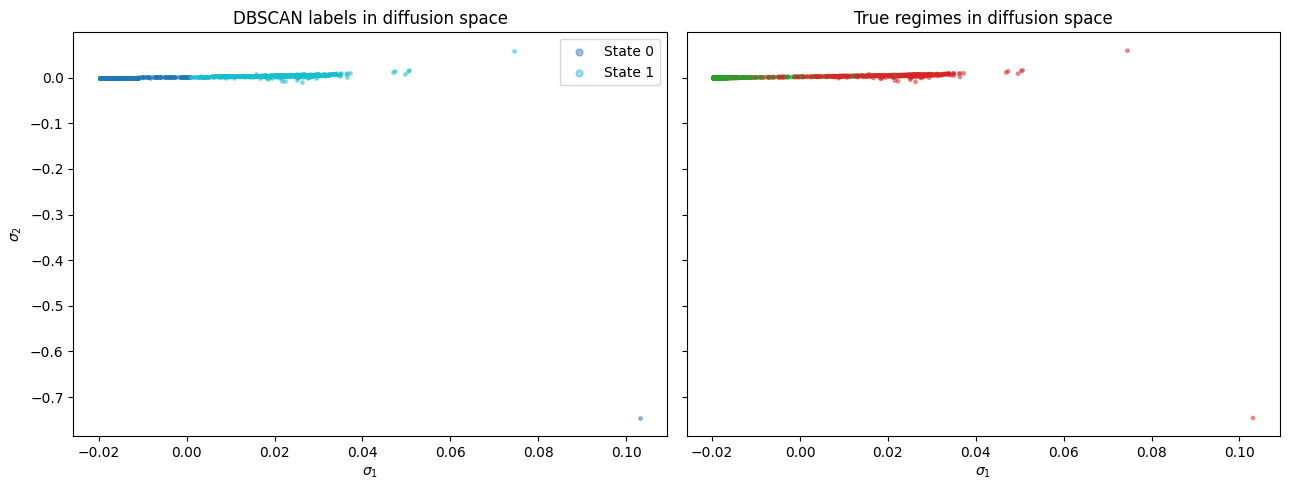

In [17]:
cluster_y = cluster_data[:, 1] if cluster_dims > 1 else np.zeros(len(cluster_data))
cluster_palette = plt.cm.tab10(np.linspace(0, 1, max(n_states, 2)))

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharex=True, sharey=True)

ax = axes[0]
for state_id in range(n_states):
    mask = labels == state_id
    ax.scatter(cluster_data[mask, 0], cluster_y[mask], s=6, alpha=0.45, color=cluster_palette[state_id], label=f'State {state_id}')
ax.set_title('DBSCAN labels in diffusion space')
ax.set_xlabel('$\\sigma_1$')
ax.set_ylabel('$\\sigma_2$' if cluster_dims > 1 else 'value')
ax.legend(markerscale=2)

ax = axes[1]
colors_gt = ['#2ca02c' if s == 0 else '#d62728' for s in states_embedded]
ax.scatter(cluster_data[:, 0], cluster_y, c=colors_gt, s=6, alpha=0.45)
ax.set_title('True regimes in diffusion space')
ax.set_xlabel('$\\sigma_1$')

plt.tight_layout()
plt.show()

## 7. Transition matrix and information measures

From the discrete state sequence $\ell_1, \ell_2, \ldots$ we estimate the Markov transition matrix

$$
T_{ij} = P(\ell_{t+1} = j \mid \ell_t = i).
$$

Then we estimate:
- the stationary distribution $\pi$, telling us how much time the process spends in each discovered state,
- the statistical complexity $C_\mu = -\sum_i \pi_i \log_2 \pi_i$, which measures how many bits are stored in the causal states,
- the entropy rate $h_\mu = -\sum_i \pi_i \sum_j T_{ij} \log_2 T_{ij}$, which measures how many bits of new information are generated per time step.

In [18]:
# Transition matrix
T = np.zeros((n_states, n_states))
for t in range(len(labels) - 1):
    T[labels[t], labels[t + 1]] += 1

# Normalize rows
row_sums = T.sum(axis=1, keepdims=True)
row_sums[row_sums == 0] = 1
T /= row_sums

print('Transition matrix (estimated):')
print(np.array2string(T, precision=4, suppress_small=True))

# True transition matrix
T_true = np.array([[p_stay_A, 1 - p_stay_A],
                    [1 - p_stay_B, p_stay_B]])
print(f"\nTransition matrix (true):")
print(np.array2string(T_true, precision=4))

# Stationary distribution
eigvals, eigvecs = np.linalg.eig(T.T)
idx_1 = np.argmin(np.abs(eigvals - 1.0))
pi = np.abs(np.real(eigvecs[:, idx_1]))
pi /= pi.sum()

print(f"\nStationary distribution (estimated) π = {pi}")
print(f"Stationary distribution (true): A={(1-p_stay_B)/((1-p_stay_A)+(1-p_stay_B)):.3f}, "
      f"B={(1-p_stay_A)/((1-p_stay_A)+(1-p_stay_B)):.3f}")

# Statistical complexity
pi_pos = pi[pi > 0]
C_mu = -np.sum(pi_pos * np.log2(pi_pos))

# Entropy rate
h_mu = 0.0
for i in range(n_states):
    for j in range(n_states):
        if T[i, j] > 0:
            h_mu -= pi[i] * T[i, j] * np.log2(T[i, j])

print(f"\nStatistical complexity = {C_mu:.4f} bits")
print(f"Entropy rate = {h_mu:.4f} bits/step")

Transition matrix (estimated):
[[0.9696 0.0304]
 [0.0966 0.9034]]

Transition matrix (true):
[[0.98 0.02]
 [0.05 0.95]]

Stationary distribution (estimated) π = [0.76080402 0.23919598]
Stationary distribution (true): A=0.714, B=0.286

Statistical complexity = 0.7937 bits
Entropy rate = 0.2590 bits/step


## 8. MMD between causal states

Maximum Mean Discrepancy (MMD) measures how far two distributions are from one another through their RKHS embeddings. Here we compare the future-window distributions $P(\mathbf{Y} \mid \text{state} = i)$ across discovered causal states.

A larger MMD means the corresponding states lead to more distinct future behavior.

In [19]:
def compute_mmd(X, Y, bandwidth):
    """Unbiased MMD^2 estimator."""
    Kxx = rbf_kernel(X, X, bandwidth)
    Kyy = rbf_kernel(Y, Y, bandwidth)
    Kxy = rbf_kernel(X, Y, bandwidth)
    n_x, n_y = X.shape[0], Y.shape[0]
    np.fill_diagonal(Kxx, 0)
    np.fill_diagonal(Kyy, 0)
    mmd2 = (Kxx.sum() / (n_x * (n_x - 1))
            - 2 * Kxy.sum() / (n_x * n_y)
            + Kyy.sum() / (n_y * (n_y - 1)))
    return max(mmd2, 0.0)

cluster_futures = [X_future_s[labels == state_id] for state_id in range(n_states)]
cluster_sizes = np.array([len(future_block) for future_block in cluster_futures])

mmd_matrix = np.zeros((n_states, n_states))
for i in range(n_states):
    for j in range(i + 1, n_states):
        mmd_value = np.sqrt(compute_mmd(cluster_futures[i], cluster_futures[j], bw_future))
        mmd_matrix[i, j] = mmd_value
        mmd_matrix[j, i] = mmd_value

print('Pairwise MMD between discovered states:')
print(np.array2string(mmd_matrix, precision=4, suppress_small=True))

largest_states = np.argsort(-cluster_sizes)
state_a = int(largest_states[0])
state_b = int(largest_states[1]) if n_states > 1 else None

futures_A = cluster_futures[state_a]
futures_B = cluster_futures[state_b] if state_b is not None else None
mmd_AB = mmd_matrix[state_a, state_b] if state_b is not None else 0.0

print(f"\nComparing the largest state: {state_a}")
print(f"  State {state_a}: n={len(futures_A)}, mean_future={futures_A.mean(axis=0)[:3].round(3)}...")
if state_b is not None:
    print(f"  State {state_b}: n={len(futures_B)}, mean_future={futures_B.mean(axis=0)[:3].round(3)}...")

Pairwise MMD between discovered states:
[[0.     0.6704]
 [0.6704 0.    ]]

Comparing the largest state: 0
  State 0: n=1515, mean_future=[0.297 0.268 0.262]...
  State 1: n=476, mean_future=[-0.944 -0.852 -0.833]...


This histogram compares the first future coordinate for the two discovered states. Less overlap means the clustering is capturing meaningfully different predictive distributions.

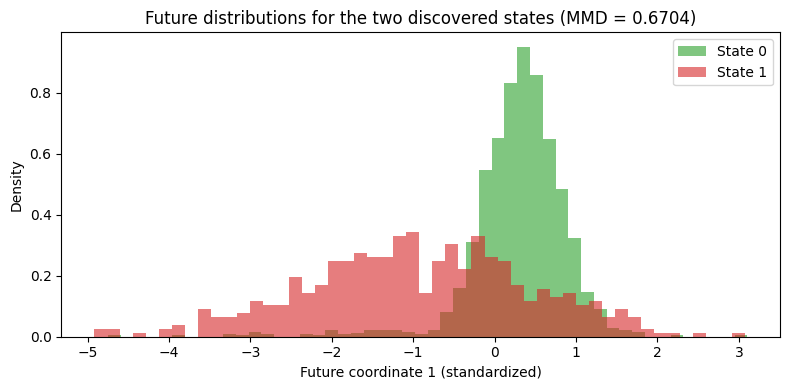

In [20]:
# Histograms of the future (first coordinate)
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(futures_A[:, 0], bins=50, alpha=0.6, color='#2ca02c', label=f'State {state_a}', density=True)
if futures_B is not None:
    ax.hist(futures_B[:, 0], bins=50, alpha=0.6, color='#d62728', label=f'State {state_b}', density=True)
ax.set_xlabel('Future coordinate 1 (standardized)')
ax.set_ylabel('Density')
title = ('Future distributions for the two discovered states '
         f'(MMD = {mmd_AB:.4f})') if futures_B is not None else 'Future distribution for the discovered state'
ax.set_title(title)
ax.legend()
plt.tight_layout()
plt.show()

## 9. Summary

Full pipeline for estimating a kernel $\epsilon$-machine:

$$
(z_0, \ldots, z_{N-1})
\xrightarrow{\text{delay embedding}} (\mathbf{x}_t, \mathbf{y}_t)
\xrightarrow{G^X,\, G^Y} \Omega = (G^X + n\varepsilon I)^{-1} G^X
\xrightarrow{G^{\mathcal{S}} = \Omega^\top G^Y \Omega} \text{diffusion map coordinates}
\xrightarrow{\text{DBSCAN}} \ell_t
\xrightarrow{\text{Information}} T_{ij},\; C_\mu,\; h_\mu.
$$